# Predict TIMSS item parameters with FastEmbed

Predict the IRT parameters of new TIMSS mathematics items from the most similar released items, whose parameters are known, as `predict_item_parameters.ipynb` does, with two differences:

- Qdrant does both the embedding and the vector storage. FastEmbed, Qdrant's embedding library, embeds the items on this computer with its default model, `BAAI/bge-small-en-v1.5`, instead of `gemini-embedding-001` through the Gemini API, and a local Qdrant collection stores the vectors.
- The LLM runs in a local Ollama server (`llama3.2` for now) instead of `google/gemini-3.8-flash` through OpenRouter. `LLM_PROVIDER` and `PARAMETER_LLM_MODEL` select another Ollama model, or a model of OpenRouter, OpenAI, or the Gemini API.

With a local LLM, the notebook needs no API key and costs nothing.
The code is in the `timss_1.parameter_prediction` modules (`src/timss_1/parameter_prediction/`, see the README), which do what `predict_item_parameters.ipynb` does with any embedding model and LLM; this notebook sets them up with FastEmbed and Ollama and shows each step.

1. Index the released items for keyword, semantic, and hybrid retrieval, and add each item's calibrated parameters to its stored metadata.
2. Predict a new item's parameters with an LLM that gets the most similar calibrated items of the same grade as context.
3. Check the method: predict calibrated released items as if they were new, compare each prediction with the item's calibrated parameters, and summarize the prediction errors by grade.

In [1]:
import logging
from pathlib import Path

import pandas as pd
from IPython.display import display
from qdrant_client import models

from timss_1.parameter_prediction import (
    EmbeddingSettings,
    IndexSettings,
    ItemBank,
    ItemIndex,
    LeaveOneOut,
    LLMSettings,
    ParameterPredictor,
    TimssItem,
    model_parameters,
    plots,
    predicted_parameters,
    results_table,
    similar_items_table,
)
from timss_1.parameter_prediction.evaluation import EXCEL_CELL_LIMIT, UNUSABLE_OUTPUT_ERRORS
from timss_1.parameter_prediction.index import NO_PARAMETERS, point_id
from timss_1.parameter_prediction.items import DUPLICATE_ITEMS, PARAMETER_LABELS
from timss_1.parameter_prediction.predictor import system_prompt

# The modules report their progress through logging; one line per HTTP request would be too many.
logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)
logging.getLogger("httpx").setLevel(logging.WARNING)

# The plots module draws matplotlib Figures without pyplot, so the inline backend must be turned on to show them.
%matplotlib inline

DATA_DIR = Path.cwd() / "data"

## Index the released items for retrieval

### One chunk per item

`ItemBank.load` reads the items and their parameters.
Every item in `data/timss_math_released_items.jsonl` (the released TIMSS and TIMSS Advanced mathematics items of 1995 to 2011, built by `get_data.ipynb`) is one chunk, except the three duplicate texts below.
The chunk's `text` is the stem followed by one line per option, which is what students read.
It is the only text that is embedded and keyword-indexed.
The correct option, scoring guide, and scoring notes are never part of it, and neither are the model-written figure descriptions or the accessibility text.

Each chunk also carries the metadata in `METADATA_FIELDS` for filters and display: item ID and label, assessment, grade, subject, content, topic, and cognitive domains, item type, maximum points, whether the item has a figure, and percent correct.
Answers and scoring guides stay out of the index altogether; look them up in the released-items JSONL by `item_key` (`bank.items_by_key`).
Item IDs alone repeat across assessments (K1 is in both TIMSS 1995 and TIMSS Advanced 1995), so `item_key` adds the assessment, grade, and subject.

### Duplicate texts left out

The 731 items have 728 distinct texts, because three items repeat another item's stem and options word for word.
The three repeats are left out of the index (`DUPLICATE_ITEMS`), so the collection holds 728 items and every text once:

| Left out | Same text as | Why the text repeats |
| --- | --- | --- |
| K7, TIMSS 1995 grade 4 | M012030, TIMSS 2003 grade 8 | TIMSS 1995 gave the item to both populations, and TIMSS 2003 gave it again at grade 8. |
| D11, TIMSS 1999 grade 8 | M012023, TIMSS 2003 grade 4 | M012023 is D11's permanent ID; TIMSS 2003 gave the item at grade 4. |
| L15B, TIMSS Advanced 1995 | L15A, TIMSS Advanced 1995 | The booklet prints the whole item on the pages of both parts, so both parts have the same text. |

A repeat has the same vectors as the item it repeats, so the two always tie and take two result places for one text.
For parameter prediction, leaving the repeats out means:

- K7 (calibrated at grade 4) and D11 (calibrated at grade 8) are neither reference items nor predicted. The items they repeat stay, with the parameters of their own grades, and similar items are only looked for within an item's grade, so the grade 4 parameters of K7 and the grade 8 parameters of D11 are not used.
- L15A and L15B have no parameters (the 1995-2008 rescaling left them out), so leaving out L15B changes no prediction.

`ItemBank.load` checks that each repeat still has the same text as the item it repeats, and that no other text repeats.
Three cross-grade pairs have nearly, but not exactly, the same text and are kept: H08 (TIMSS 1999 grade 8) and M012044 (TIMSS 2003 grade 4), and H12 and M012048, are the same items under booklet and permanent IDs with slightly different transcriptions, and M031334 (TIMSS 2007 grade 4) and M032273 (TIMSS 2007 grade 8) are one item with options B and C swapped.
Each copy is calibrated at its own grade, and same-grade retrieval never puts the two copies in each other's context.

In [2]:
bank = ItemBank.load(DATA_DIR)
chunks_table = pd.DataFrame(bank.chunks)
print(f"{len(bank.chunks)} chunks: {len(bank.items_by_key)} items, {len(DUPLICATE_ITEMS)} duplicate texts left out")
display(chunks_table.groupby(["assessment", "grade", "subject"]).size().rename("items").to_frame())
display(chunks_table["text"].str.len().describe().round().rename("text characters").to_frame().T)
display(chunks_table.head())

728 chunks: 731 items, 3 duplicate texts left out


items
assessment          grade subject                    
TIMSS 1995          4     Mathematics              69
TIMSS 1999          8     Mathematics              81
TIMSS 2003          4     Mathematics              79
                    8     Mathematics              99
TIMSS 2007          4     Mathematics              74
                    8     Mathematics              89
TIMSS 2011          4     Mathematics              73
                    8     Mathematics              88
TIMSS Advanced 1995 12    Advanced Mathematics     36
TIMSS Advanced 2008 12    Advanced Mathematics     40

,count,mean,std,min,25%,50%,75%,max
text characters,728.0,250.0,230.0,22.0,124.0,195.0,294.0,2451.0


,item_key,item_id,item_label,assessment,grade,subject,content_domain,main_topic,cognitive_domain,item_type,max_points,has_figure,pct_correct_intl_avg,pct_correct_usa,text
0,TIMSS 1995/grade 4/Mathematics/I3,I3,Which number is it,TIMSS 1995,4,Mathematics,Whole Numbers,NaN,Using Complex Procedures,multiple_choice,1,False,57.0,57.0,When you subtract one of the numbers below fro...
1,TIMSS 1995/grade 4/Mathematics/I4,I4,What is 3 times 23,TIMSS 1995,4,Mathematics,Whole Numbers,NaN,Performing Routine Procedures,multiple_choice,1,False,84.0,90.0,What is 3 times 23?\n\nA. 323\nB. 233\nC. 69\n...
2,TIMSS 1995/grade 4/Mathematics/I9,I9,Subtraction of 4 digit numbers,TIMSS 1995,4,Mathematics,Whole Numbers,NaN,Performing Routine Procedures,multiple_choice,1,False,71.0,71.0,"Subtract:\n\n 6,000\n−2,369\n____\n\nA. 4,369..."
3,TIMSS 1995/grade 4/Mathematics/J4,J4,What is the increase in product,TIMSS 1995,4,Mathematics,Whole Numbers,NaN,Using Complex Procedures,multiple_choice,1,False,45.0,46.0,25 × 18 is more than 24 × 18. How much more?\n...
4,TIMSS 1995/grade 4/Mathematics/J9,J9,Number in box,TIMSS 1995,4,Mathematics,Whole Numbers,NaN,Performing Routine Procedures,multiple_choice,1,True,73.0,83.0,Here is part of a wall chart that lists number...


### Embed the chunks with FastEmbed and store them in Qdrant

`ItemIndex.build` embeds the chunks and stores them, with their calibrated parameters (see below), in a Qdrant collection.

FastEmbed's default model, `BAAI/bge-small-en-v1.5`, embeds the text of each chunk as a 384-dimensional unit vector, so cosine similarity is a dot product.
The model runs on this computer with ONNX Runtime, so embedding needs no API key and has no quota.
FastEmbed downloads it (67 MB) from Hugging Face on first use, into `FASTEMBED_CACHE_PATH` if that is set and otherwise into `fastembed_cache` in the system temp directory; `EmbeddingSettings(fastembed_cache_dir=...)` names another directory.

Each text is embedded on its own.
In a batch, a text's vector depends slightly on the other texts of the batch (by up to 0.0002 in a dimension), so the same text could get different vectors in different runs and change the cosine similarities in the prompts; alone, a text always gets the same vector, and all 728 take about 5 seconds.
bge-small-en-v1.5 embeds search queries and documents alike (FastEmbed adds no query instruction for it), so queries, new items, and the stored items are all embedded the same way.

The model reads at most 512 tokens of a text, and the cell lists the texts that reach this limit.
Three texts are longer, about 900 tokens each: the three parts of the class trip task of TIMSS 2007 grade 8 (M032753A to M032753C), whose stem holds two bus timetables.
Their vectors cover only their first 512 tokens, which are the same in the three parts; keyword search still covers their whole text.

The vectors are cached in `data/cache/item_embeddings/`, in a file named for the embedding settings, in chunk order with each item's key and the SHA-256 hash of its text.
A rebuild reuses the vector of every unchanged text and embeds only the others, so a new version of FastEmbed or ONNX Runtime, whose vectors may differ in the last digits, does not change the prompts of unchanged items.
`uv run timss-predict-loo --embedding-provider fastembed` reads the same file.

The local Qdrant collection `timss_math_items` (in `data/qdrant_timss_math_items_fastembed/`) holds one point per chunk, with the chunk and its parameters as its payload and two named vectors:

- `dense`, the FastEmbed embedding, compared by cosine similarity, for semantic retrieval.
- `bm25`, a sparse BM25 vector of the text, for keyword retrieval. Qdrant keeps sparse vectors in an inverted index and computes each term's inverse document frequency over the collection at query time (the IDF modifier), so the stored vector holds only the BM25 term-frequency part.

Keyword terms are lowercase words, folded to the singular by Harman's S stemmer, and numbers without thousands separators, so "1,000 marbles" matches "1000 marble".
The index of a term in a sparse vector is a 32-bit hash of the term, so no vocabulary has to be stored.
The keyword vectors are the same as in `predict_item_parameters.ipynb`, so keyword search finds the same items there and here, and only semantic and hybrid search differ.

Rerunning the cell rebuilds the collection from the cached vectors.
The storage is separate from `data/qdrant_timss_math_items/`, which holds the Gemini embeddings and which the kernel of `predict_item_parameters.ipynb` locks while its client is open, so both notebooks can run at once.
This notebook's kernel likewise locks `data/qdrant_timss_math_items_fastembed/` until `index.close()`; `timss-predict-loo` keeps its collection in memory, so it can run meanwhile.
Local Qdrant filters by scanning the payloads, which is fast at this size; on a Qdrant server (`IndexSettings(url=...)`), add payload indexes for the fields you filter on.

In [3]:
# FastEmbed's default model; FastEmbed cannot shorten vectors, so the dimension is the model's own.
EMBEDDING = EmbeddingSettings(provider="fastembed", model="BAAI/bge-small-en-v1.5", dimension=None)
QDRANT = IndexSettings(collection="timss_math_items", path=DATA_DIR / "qdrant_timss_math_items_fastembed")

if "index" in globals():
    index.close()  # releases the lock on the local storage, so that the cell can be rerun
index = ItemIndex.build(EMBEDDING, QDRANT, bank=bank, data_dir=DATA_DIR)
embedder = index.embedder
print(
    f"{len(index.vectors_by_hash)} item embeddings of {EMBEDDING.model}, {embedder.fastembed_model.embedding_size} "
    f"dimensions, cached in {EMBEDDING.default_cache_path(DATA_DIR).relative_to(DATA_DIR.parent)}"
)
print(f"Stored {index.client.count(QDRANT.collection, exact=True).count} items in collection '{QDRANT.collection}' at {QDRANT.path}")
print(f"Texts that reach the model's limit of {embedder.fastembed_max_tokens} tokens, where longer texts are cut:")
for chunk in bank.chunks:
    if embedder.reaches_input_limit(chunk["text"]):
        print(f"  {chunk['item_key']}")

728 texts already embedded, 0 to embed
Stored 728 items, 722 with parameters, in collection 'timss_math_items'


728 item embeddings of BAAI/bge-small-en-v1.5, 384 dimensions, cached in data/cache/item_embeddings/fastembed_BAAI_bge-small-en-v1.5_full_cbabfb0e.npz
Stored 728 items in collection 'timss_math_items' at /Users/ze/Documents/projects/timss-1/notebooks/data/qdrant_timss_math_items_fastembed
Texts that reach the model's limit of 512 tokens, where longer texts are cut:
  TIMSS 2007/grade 8/Mathematics/M032753A
  TIMSS 2007/grade 8/Mathematics/M032753B
  TIMSS 2007/grade 8/Mathematics/M032753C


### Search the collection

`index.search(text, method)` returns the items that best match `text`, best first:

- `"keyword"` ranks items by the BM25 score of their stem and options.
- `"semantic"` ranks them by the cosine similarity of their embedding with the embedding of `text`.
- `"hybrid"` (the default) fuses the keyword and semantic rankings, each of up to `IndexSettings.hybrid_candidates` (50) items, by reciprocal rank fusion, so items ranked high by either method or by both come first. Its scores are fusion scores, not similarities.

`query_filter` keeps any method to items with the given metadata; `index.metadata_filter` builds one from field values, where a list accepts any of its values.
`text` is embedded as a search query, which bge-small-en-v1.5 embeds as it embeds items; `embed_as="document"` embeds it as an item, to find the items most similar to an item with a model that tells them apart.
`vector` passes the embedding of `text` when it is already known, such as a stored item's, so it is not embedded again.

In [4]:
query = "fraction of a shape that is shaded"
for method in ("keyword", "semantic", "hybrid"):
    print(method)
    display(results_table(index.search(query, method, limit=5)))

print("hybrid, grade 4 items of TIMSS 2007 and 2011")
display(
    results_table(
        index.search(query, limit=5, query_filter=index.metadata_filter(assessment=["TIMSS 2007", "TIMSS 2011"], grade=4))
    )
)

keyword


,score,assessment,grade,item_id,content_domain,text
0,11.020040,TIMSS 1995,4,J7,Fractions and Proportionality,Part of the figure is shaded. [Image: A 3x3 gr...
1,10.896976,TIMSS 2003,4,M031347C,Number,C. What fraction of the figure is shaded in pa...
2,10.777558,TIMSS 2007,4,M041006,Number,What fraction of this rectangle is shaded? [Im...
3,9.750047,TIMSS 2007,8,M022043,Number,[Image: Rectangle divided into 12 squares with...
4,9.490537,TIMSS 2007,4,M041173,Geometric Shapes and Measures,[Image: A shaded geometric shape] The shape ab...


semantic


,score,assessment,grade,item_id,content_domain,text
0,0.851938,TIMSS 2003,4,M031347C,Number,C. What fraction of the figure is shaded in pa...
1,0.850286,TIMSS 1995,4,J7,Fractions and Proportionality,Part of the figure is shaded. [Image: A 3x3 gr...
2,0.843916,TIMSS 2007,4,M041006,Number,What fraction of this rectangle is shaded? [Im...
3,0.788288,TIMSS 1999,8,F12,Fractions and Number Sense,What fraction of the circle is shaded? [Image:...
4,0.783930,TIMSS 2007,8,M022043,Number,[Image: Rectangle divided into 12 squares with...


hybrid


,score,assessment,grade,item_id,content_domain,text
0,0.833333,TIMSS 1995,4,J7,Fractions and Proportionality,Part of the figure is shaded. [Image: A 3x3 gr...
1,0.833333,TIMSS 2003,4,M031347C,Number,C. What fraction of the figure is shaded in pa...
2,0.500000,TIMSS 2007,4,M041006,Number,What fraction of this rectangle is shaded? [Im...
3,0.366667,TIMSS 2007,8,M022043,Number,[Image: Rectangle divided into 12 squares with...
4,0.342857,TIMSS 1999,8,F12,Fractions and Number Sense,What fraction of the circle is shaded? [Image:...


hybrid, grade 4 items of TIMSS 2007 and 2011


,score,assessment,grade,item_id,content_domain,text
0,1.000000,TIMSS 2007,4,M041006,Number,What fraction of this rectangle is shaded? [Im...
1,0.533333,TIMSS 2007,4,M041173,Geometric Shapes and Measures,[Image: A shaded geometric shape] The shape ab...
2,0.366667,TIMSS 2007,4,M031271,Geometric Shapes and Measures,The square is cut into 7 pieces. Put an X on e...
3,0.333333,TIMSS 2011,4,M041064,Number,Shade 1/2 of the large triangle. [Image: a lar...
4,0.309524,TIMSS 2011,4,M041284,Geometric Shapes and Measures,"[Image: various shapes labeled A, B, C, D, E, ..."


In [5]:
# The items most similar to one released item, the item itself left out. The other parts of a multi-part item, and the
# other items of its task (M031379 and M031380 here), share its stimulus, so they rank first.
example_key = "TIMSS 2011/grade 4/Mathematics/M031346A"
display(
    results_table(
        index.search(
            bank.item(example_key).text,
            limit=5,
            query_filter=models.Filter(must_not=[models.HasIdCondition(has_id=[point_id(example_key)])]),
            embed_as="document",
        )
    )
)

,score,assessment,grade,item_id,content_domain,text
0,1.000000,TIMSS 2011,4,M031346C,Number,The town fair had a booth where people could t...
1,0.666667,TIMSS 2011,4,M031346B,Number,The town fair had a booth where people could t...
2,0.500000,TIMSS 2011,4,M031379,Number,Trading Cards (Continued) Trading Sports Cards...
3,0.400000,TIMSS 2011,4,M031380,Number,Trading Cartoon Cards Brad had 8 cartoon cards...
4,0.226190,TIMSS 2011,4,M041115B,Number,Bill is arranging squares in the following way...


## Add the item parameters to the stored metadata

`data/timss_math_released_item_parameters.xlsx` (sheet `item_parameters`, written by `get_data.ipynb` and documented in `timss_math_released_items.md`) has the official IRT parameters of the released items.
`ItemIndex.build` gives each item in the collection its parameters as an `item_parameters` payload object, matched by `item_key`:

- `irt_model`: 3PL, 2PL, or GPCM.
- `scaled_points`: the item's points in the IRT scaling, 1 for a 3PL or 2PL item and the number of steps for a GPCM item.
- `slope`, `location`, `guessing`, `step1`, `step2`, and `step3`: the estimates, null for parameters the model does not have.
- `slope_se` and so on: the standard error of each estimate.
- `calibration`: the concurrent calibration the parameters come from.

`ItemBank.load` checks that every item in the collection has a row in the workbook, that each item's model fits its format (3PL for multiple choice, 2PL for a constructed-response item worth 1 point in the scaling, GPCM with one step per point for one worth more), and that the steps of every GPCM item sum to 0.
K14 and L18 of TIMSS Advanced 1995 are worth 2 points in the 1995 coding guide but were scaled as 1-point items, so they are 2PL items with `scaled_points` 1.

Six items in the collection have no parameters, so their `item_parameters` is null: K8, K9, L10, L11, and L15A of TIMSS Advanced 1995, which the 1995-2008 rescaling left out, and M042273 of TIMSS 2007 grade 8, which was not used in scaling.
They stay in the collection for search but are never reference items, and they are not predicted.

Within a grade, the parameters come from different concurrent calibrations.
At grade 4, the TIMSS 1995 and 2003 items come from the joint 1995-2003 calibration, the TIMSS 2007 items from the joint 2003-2007 calibration, and the TIMSS 2011 items from the 2007-2011 calibration; grade 8 is the same with 1999 in place of 1995.
TIMSS links each calibration to the one before through trend items, so their scales are close but not identical.
TIMSS Advanced 1995 and 2008 share one calibration.

`bank.calibrated` holds the parameters of the items in the collection that have them, one row per item.

In [6]:
calibrated = bank.calibrated
stored_with_parameters = index.client.count(
    QDRANT.collection, count_filter=models.Filter(must_not=[NO_PARAMETERS]), exact=True
).count
print(f"Added parameters to {stored_with_parameters} of {len(bank.chunks)} items in '{QDRANT.collection}'")
display(pd.crosstab([calibrated["grade"], calibrated["assessment"]], calibrated["irt_model"], margins=True))
print("Items without parameters:")
display(
    chunks_table.loc[~chunks_table["item_key"].isin(calibrated.index), ["assessment", "grade", "item_id"]].reset_index(
        drop=True
    )
)
scaled_differently = calibrated[calibrated["scaled_points"] != calibrated["max_points"]]
print("Items whose points in the scaling differ from their maximum points:")
display(
    scaled_differently[["assessment", "item_id", "item_type", "max_points", "scaled_points", "irt_model"]].reset_index(
        drop=True
    )
)

Added parameters to 722 of 728 items in 'timss_math_items'


irt_model                  2PL  3PL  GPCM  All
grade assessment                              
4     TIMSS 1995            22   41     6   69
      TIMSS 2003            25   51     3   79
      TIMSS 2007            35   36     3   74
      TIMSS 2011            31   36     6   73
8     TIMSS 1999            14   64     3   81
      TIMSS 2003            21   72     6   99
      TIMSS 2007            27   50    11   88
      TIMSS 2011            30   48    10   88
12    TIMSS Advanced 1995    6   19     6   31
      TIMSS Advanced 2008   13   25     2   40
All                        224  442    56  722

Items without parameters:


,assessment,grade,item_id
0,TIMSS Advanced 1995,12,K8
1,TIMSS Advanced 1995,12,K9
2,TIMSS Advanced 1995,12,L10
3,TIMSS Advanced 1995,12,L11
4,TIMSS Advanced 1995,12,L15A
5,TIMSS 2007,8,M042273


Items whose points in the scaling differ from their maximum points:


,assessment,item_id,item_type,max_points,scaled_points,irt_model
0,TIMSS Advanced 1995,K14,constructed_response,2,1,2PL
1,TIMSS Advanced 1995,L18,constructed_response,2,1,2PL


## Predict the parameters of a new item

`predictor.predict(item)` (`ParameterPredictor`) predicts the IRT parameters of a new item in two steps.

1. `index.find_similar_items` returns the calibrated items of the collection most similar to the new item, only from the item's grade.
   It searches with the item's text (stem and options) by `SIMILAR_ITEMS_METHOD`, hybrid search by default, so items that share the new item's words or meaning rank first.
   The new item is embedded like the stored items, so its cosine similarities with them are comparable; an item whose text is in the collection reuses its stored vector.
   Items without parameters, and the items in `exclude_keys`, are never returned.
2. An LLM (`PARAMETER_LLM_MODEL` of `LLM_PROVIDER`, `llama3.2` in a local Ollama server for now) gets the similar items as context and returns the new item's parameters and its reasoning in a structured-output schema.

The context holds the `N_SIMILAR` most similar items of any format, then the `N_SAME_MODEL` most similar items scored with the new item's IRT model and points that are not among them, so the LLM always sees calibrated examples of every parameter it predicts.
For each of these reference items, the LLM gets the whole item (classification, format, stem, the model-written figure description, options and correct option or scoring guide), its cosine similarity with the new item, its international average percent correct, its calibration, and its calibrated parameters.
It also gets a calibration summary: the distribution of each parameter over all calibrated items of the grade scored with the same model and points, without the new item.
The new item's own percent correct is never given, since a new item has none.

The IRT model follows the item's format and points, as in the TIMSS scaling:

| Item | IRT model | Parameters | The LLM predicts |
| --- | --- | --- | --- |
| Multiple choice | 3PL | slope (a), location (b), guessing (c) | all three |
| Constructed response worth 1 point (scored 0 or 1) | 2PL | slope, location | both |
| Constructed response worth m > 1 points (partial credit) | GPCM | slope, location, steps d_1 to d_m | slope, location, d_1 to d_(m-1) |

The steps of every calibrated GPCM item sum to 0, so the last step is minus the sum of the others; for a 2-point item, step 2 is minus step 1.

The system prompt (`system_prompt`) makes the LLM an expert in testing the subject for the item's grade who is very familiar with the item's content domain (and main topic, where the framework has one) and cognitive domain, and a measurement expert in IRT models.
It states the three models with the TIMSS scaling constant 1.7, explains each parameter, says the reference items come from linked but not identical calibrations, and asks the LLM to first compare the new item with the reference items and then give its reasoning for each parameter before the value.

A new item is a `TimssItem`, with the fields of the released-items JSONL that describe it.
Its `assessment` names the calibration whose scale the prediction targets (`bank.calibrations`); for an assessment without calibrated items, the prompt asks for the scale of the most recent calibration among the reference items.
`predictor.prepare` finds the reference items and writes the prompts without calling the LLM, `predictor.request` sends the prompts, and `predictor.predict` does both.

`LLMSettings` takes the LLM: Ollama's chat API gets the structured-output schema as `format`, the reasoning effort as `think`, and the context window as `num_ctx`; OpenRouter, OpenAI, and the Gemini API are called through their OpenAI-compatible APIs with the key from the project `.env` (`OPENROUTER_API_KEY`, `OPENAI_API_KEY`, `GEMINI_API_KEY`).
`llama3.2` cannot reason, so it gets no reasoning effort.
Its replies, usually 500 to 1,500 tokens, fit well within `PARAMETER_MAX_TOKENS`, which stops a reply that repeats itself; `llama3.2` sometimes does, and a rerun usually succeeds.

In [7]:
SIMILAR_ITEMS_METHOD = "hybrid"  # "keyword", "semantic", or "hybrid"; see index.search
N_SIMILAR = 10  # most similar items of any format
N_SAME_MODEL = 5  # most similar items scored with the new item's IRT model and points, if not among the N_SIMILAR

LLM_PROVIDER = "ollama"  # "ollama" (a local Ollama server), "openrouter", "openai", or "gemini" (the Gemini API)
PARAMETER_LLM_MODEL = "llama3.2"  # the provider's name of the model, such as "google/gemini-3.8-flash" on OpenRouter
# "low", "medium", or "high" for a model that can reason (Ollama also takes True or False); None sends none, as llama3.2
# cannot reason.
PARAMETER_REASONING_EFFORT = None
PARAMETER_MAX_TOKENS = 4096  # output cap, reasoning included; a reasoning model may need more, such as 16384
OLLAMA_NUM_CTX = 32768  # Ollama's context window in tokens, which must hold the prompts (about 6,000 tokens) and output

LLM = LLMSettings(
    provider=LLM_PROVIDER,
    model=PARAMETER_LLM_MODEL,
    reasoning_effort=PARAMETER_REASONING_EFFORT,
    max_tokens=PARAMETER_MAX_TOKENS,
    ollama_num_ctx=OLLAMA_NUM_CTX,
)
predictor = ParameterPredictor(
    index, LLM, search_method=SIMILAR_ITEMS_METHOD, n_similar=N_SIMILAR, n_same_model=N_SAME_MODEL
)

### Example: a new item

A made-up grade 4 multiple-choice item, predicted on the scale of the TIMSS 2011 calibration.
It costs one LLM request, or a few if the output is unusable; `llama3.2` in Ollama answers in about 10 seconds here.

In [8]:
new_item = TimssItem(
    assessment="TIMSS 2011",
    grade=4,
    subject="Mathematics",
    content_domain="Number",
    main_topic="Whole Numbers",
    cognitive_domain="Applying",
    item_type="multiple_choice",
    stem="Maria had 52 stickers. She gave 18 stickers to her brother. How many stickers does Maria have now?",
    options=[
        {"label": "A", "text": "34"},
        {"label": "B", "text": "44"},
        {"label": "C", "text": "46"},
        {"label": "D", "text": "70"},
    ],
    correct_option="A",
)
print(f"Most similar calibrated grade {new_item.grade} items (the new item is scored with the {new_item.irt_model} model):")
display(
    similar_items_table(index.find_similar_items(new_item, limit=5, method=SIMILAR_ITEMS_METHOD))
    .dropna(axis=1, how="all")
    .round(3)
)
print(f"System prompt:\n\n{system_prompt(new_item)}\n")

# A small local model sometimes repeats itself until PARAMETER_MAX_TOKENS, or writes output that does not fit the schema.
# Such output is requested again, up to three requests in all.
for attempt in range(1, 4):
    try:
        new_item_prediction = predictor.predict(new_item)
        break
    except UNUSABLE_OUTPUT_ERRORS as error:
        print(f"Request {attempt}: unusable output ({type(error).__name__}: {error})")
else:
    raise RuntimeError("Three requests gave no usable prediction")
names = model_parameters(new_item.irt_model, new_item.points)
display(pd.DataFrame([{name: new_item_prediction[name] for name in names}], index=["predicted"]).round(3))
print(f"Reasoning: {new_item_prediction['reasoning']}")
for name in predicted_parameters(new_item.irt_model, new_item.points):
    print(f"{PARAMETER_LABELS[name]}: {new_item_prediction[f'{name}_reasoning']}")

Most similar calibrated grade 4 items (the new item is scored with the 3PL model):


,rank,cosine_similarity,assessment,item_id,content_domain,cognitive_domain,item_type,pct_correct_intl_avg,irt_model,scaled_points,slope,location,guessing
0,1,0.782,TIMSS 2007,M031173,Number,Applying,multiple_choice,57.6,3PL,1,1.559,-0.146,0.125
1,2,0.748,TIMSS 2007,M031134,Data Display,Applying,constructed_response,27.7,2PL,1,0.570,0.851,NaN
2,3,0.641,TIMSS 2011,M031187,Number,Applying,multiple_choice,73.0,3PL,1,0.679,-0.897,0.198
3,4,0.748,TIMSS 1995,M2,"Data Representation, Analysis, and Probability",Using Complex Procedures,constructed_response,55.0,2PL,1,0.688,-0.205,NaN
4,5,0.741,TIMSS 2011,M041158,Geometric Shapes and Measures,Applying,multiple_choice,63.0,3PL,1,0.759,-0.462,0.223


System prompt:

You are an expert in testing mathematics for fourth-grade students. You are very familiar with assessing these students in the Number content domain, especially Whole Numbers, and in the Applying cognitive domain, as the TIMSS 2011 framework defines them. You have written, reviewed, and analyzed many mathematics items for these students, and you know from experience how students across the TIMSS countries perform on them.

You are also a measurement expert in item response theory (IRT). You know the three-parameter logistic (3PL), two-parameter logistic (2PL), and generalized partial credit (GPCM) models, how TIMSS calibrates items with them, and how content, cognitive demand, the number and difficulty of steps, the numbers involved, reading load, figures, response format, distractor plausibility, and scoring rules shape item parameters.

Your task is to predict the IRT parameters that a new item would receive in a TIMSS calibration, using calibrated reference items of 

,slope,location,guessing
predicted,1.021,-0.249,0.207


Reasoning: This item should be easier than M031187. The problem is simpler and doesn't require the same level of reasoning as M031187. In addition, the number of pencils Pete had is larger than the number of pencils Maria has.
slope (a): The new item should have a higher slope (a) than M031187. The slope (a) measures the discrimination of the item. A higher slope indicates that the item is more difficult and requires more reasoning. The new item is similar to M031187 in terms of the type of question (whole number problems), but it should be easier than M031187.
location (b): The new item should have a lower location (b) than M031187. The location (b) measures the overall difficulty of the item. A lower location indicates that the item is easier and is a good starting point for students. The new item should be slightly easier than M031187.
guessing (c): The new item should have a higher guessing (c) than M031187. The guessing (c) measures the chance that a student of very low ability wi

## Predict every calibrated item as if it were new

`LeaveOneOut(predictor)` predicts every item in the collection that has parameters as if it were new, and the prediction is compared with the item's calibrated parameters.

- The item and its other parts are left out of its context, both as reference items and from the calibration summary (`bank.parts`). The other parts are the items of the same assessment and grade whose IDs differ only in a final part letter (`base_item_id`), such as M031346B and M031346C for M031346A, V4B for V4A, or T02B for T02A, and the other items of the same task (below).
- The item's own percent correct is not in its prompt.
- Each item is predicted with the IRT model and points of its calibration, so K14 and L18 of TIMSS Advanced 1995 are predicted as 1-point (2PL) items, and its `assessment` makes the prediction target the scale of its own calibration.
- Each item reuses its stored vector, so the run embeds no text.

Some items belong to a task of several items built around one situation, but have IDs of their own, so their IDs do not show that they belong together.
For example, M031379 and M031380 continue the Trading Cards situation of M031346A to M031346C on a page headed "Trading Cards (Continued)", so when M031346A is predicted, M031346B, M031346C, M031379, and M031380 are all left out.
`SHARED_STIMULUS_TASKS` (in `timss_1.parameter_prediction.items`) lists these tasks, found by comparing the stems and labels of the items of each assessment (shared passages, and labels such as "Trading Cards_Cartoon cards" and "Trading Cards_Trading sports cards"):

| Assessment | Grade | Task | Items |
| --- | --- | --- | --- |
| TIMSS 2003 | 4 | Bar graph of the bottles each class collected | M011009, M011012 |
| TIMSS 2003 | 4 | Number tiles | M031344A to M031344C, M031345A to M031345C |
| TIMSS 2003 | 8 | Geometry tiling | M032743, M032744, M032745 |
| TIMSS 2003 | 8 | Phone plans | M032762, M032763, M032764 |
| TIMSS 2007 | 8 | Class trip | M032753A to M032753C, M032754, M032755, M032756 |
| TIMSS 2011 | 4 | Trading cards | M031346A to M031346C, M031379, M031380 |
| TIMSS 2011 | 8 | Red and black tiles | M032757, M032760A to M032760C, M032761 |

Items that merely share wording, such as the coordinate-grid items M031088 and M041160A of TIMSS 2011 grade 4, are not tasks.

The first cell finds the reference items and writes the prompts of every item, which needs no LLM requests, and compares them with the saved predictions.
The second cell requests at most `LOO_MAX_REQUESTS` of the predictions that are missing, or whose prompts, LLM, or reasoning effort changed since they were saved, `PREDICTION_WORKERS` at a time.
A local LLM takes seconds to minutes per item, so predicting all 722 items takes hours; set `LOO_MAX_REQUESTS = None` to request all of them.
Each prediction is saved as it arrives in `data/cache/parameter_predictions/timss_math/<provider>/<model>/`, one JSON file per item and prompt, named by the item and a hash of the LLM provider, model, reasoning effort, and both prompts, so the `timss-predict-loo` command with the same settings reuses them.
The file holds the item, its reference items, the prompts, the LLM's reasoning and parameters, and the token usage.
So an interrupted run resumes where it stopped, a rerun with unchanged prompts sends no requests, and predictions from other embedding models or LLMs are never overwritten.
An item whose output does not fit the schema, or is cut off at `PARAMETER_MAX_TOKENS` (as when a small model repeats itself), is reported and left for a rerun; any other error, such as an Ollama server that is not running, stops the cell.

In [9]:
PREDICTION_WORKERS = 1  # concurrent LLM requests; an Ollama server answers as many at once as OLLAMA_NUM_PARALLEL allows
LOO_MAX_REQUESTS = 10  # predictions to request at most in a run of the next cell; None requests every missing one
PREDICTIONS_PATH = DATA_DIR / "timss_math_predicted_item_parameters_fastembed.xlsx"

loo = LeaveOneOut(predictor, data_dir=DATA_DIR)
loo_prepared = loo.prepared  # the reference items and prompts of every item, found without LLM requests

multi_part = [key for key in loo.items if len(bank.parts[key]) > 1]
print(f"{len(multi_part)} items have other parts, which their predictions leave out; for example:")
for key in ["TIMSS 2011/grade 4/Mathematics/M031346A", "TIMSS 2003/grade 8/Mathematics/M032743"]:
    print(f"  {key}: {', '.join(bank.items_by_key[part]['item_id'] for part in bank.parts[key] if part != key)}")

context = pd.DataFrame(
    {
        "grade": [item.grade for item in loo.items.values()],
        "reference_items": [len(prepared["references"]) for prepared in loo_prepared.values()],
        "prompt_characters": [
            len(prepared["system_prompt"]) + len(prepared["user_prompt"]) for prepared in loo_prepared.values()
        ],
    }
)
display(context.groupby("grade").agg(["mean", "min", "max"]).round())

print(f"Predictions with {LLM.model} ({LLM.provider}) in {loo.cache.directory.relative_to(DATA_DIR.parent)}:")
display(loo.status().value_counts().rename("items").to_frame())

Prepared 722 items in 17 s


111 items have other parts, which their predictions leave out; for example:
  TIMSS 2011/grade 4/Mathematics/M031346A: M031346B, M031346C, M031379, M031380
  TIMSS 2003/grade 8/Mathematics/M032743: M032744, M032745


reference_items         prompt_characters              
                 mean min max              mean    min    max
grade                                                        
4                11.0  10  15           18642.0  11032  36175
8                11.0  10  15           18243.0  10789  34529
12               11.0  10  15           21079.0  11352  32348

Predictions with llama3.2 (ollama) in data/cache/parameter_predictions/timss_math/ollama/llama3.2:


,items
status,
not predicted yet,702
saved,20


In [10]:
report = loo.request(LOO_MAX_REQUESTS, PREDICTION_WORKERS)
print(f"Requested {report.requested} predictions in {report.seconds:.0f} s; {report.saved} were saved")
for key, error in report.unusable.items():
    print(f"  unusable output, left for a rerun: {key}: {error}")
print(f"{len(loo.saved())} of {len(loo.items)} items are predicted")

Requesting 10 predictions from llama3.2 (ollama), 1 at a time
TIMSS 1995/grade 4/Mathematics/T4B: unusable output (NoPredictionError), left for a rerun
10/10 in 152 s, $0.00


Requested 10 predictions in 152 s; 9 were saved
  unusable output, left for a rerun: TIMSS 1995/grade 4/Mathematics/T4B: NoPredictionError: Output cut off at max_tokens (4096)
29 of 722 items are predicted


### Prediction errors

`results.predictions` (from `loo.results()`) has one row per item, with every column of the prediction process:

- The item: key, assessment, grade, subject, ID, label, content domain, main topic, cognitive domain, format, maximum points and points in the scaling, IRT model, and the calibration of its parameters.
- Its context: the other parts left out (`excluded_item_ids`, including the other items of its task), the number of reference items and their IDs in prompt order (`similar_item_ids`), and `similar_items`, which gives, as JSON, each reference item's rank, how it was found (among the `N_SIMILAR` most similar items, or among those with the same model), assessment, cosine similarity, percent correct, and calibrated parameters.
- The LLM's output: `reasoning`, its comparison of the item with the reference items, and its reasoning for each parameter it predicted (`slope_reasoning` and so on), plus `llm_thinking`, the reasoning summary the model returned, if any.
- For each parameter: the predicted value (`slope_predicted`), the calibrated value (`slope_calibrated`), the prediction error, predicted minus calibrated (`slope_error`), and its absolute value (`slope_abs_error`). Parameters that the item's model lacks are blank. The last step of a GPCM item is derived from the others, so its error mirrors theirs.
- The LLM provider and model and the reasoning effort, finish reason, token counts, cost in US dollars (none for Ollama), time of the prediction (UTC), both prompts, and the name of the file in `data/cache/parameter_predictions/timss_math/<provider>/<model>/` that the prediction is saved in.

`predictions` is exported to `data/timss_math_predicted_item_parameters_fastembed.xlsx` (sheet `predictions`), with the error summaries below in sheets of their own.
An Excel cell holds at most 32,767 characters, so a longer text, such as a long prompt, is cut there in the workbook; the saved prediction has it in full.

In [11]:
results = loo.results()
predictions = results.predictions
print(f"{len(predictions)} items predicted with {LLM.model} ({LLM.provider})")
display(
    predictions[["assessment", "item_id", "irt_model", "excluded_item_ids", "location_predicted", "location_calibrated", "location_error"]]
    .head()
    .round(3)
)

693 items have no current prediction and are left out


29 items predicted with llama3.2 (ollama)


,assessment,item_id,irt_model,excluded_item_ids,location_predicted,location_calibrated,location_error
0,TIMSS 1995,I3,3PL,,-0.100,0.111,-0.211
1,TIMSS 1995,I4,3PL,,0.200,-1.368,1.568
2,TIMSS 1995,I9,3PL,,-0.776,-0.297,-0.479
3,TIMSS 1995,J4,3PL,,-0.442,0.521,-0.963
4,TIMSS 1995,J9,3PL,,-1.550,-0.761,-0.789


### Prediction error by grade

The summary covers the parameters that the LLM predicts, for every item whose model has them; the last step of a GPCM item is derived, so it is left out.
For each grade and parameter, it gives:

- `items`: the number of items.
- `mean_error`: the bias, the mean of predicted minus calibrated values.
- `sd_error`, `mean_absolute_error`, and `rmse` (root mean squared error).
- `correlation`: the correlation of the predicted with the calibrated values.
- Two baselines that need no LLM, as mean absolute errors. `baseline_mae_calibration_mean` predicts each item's parameter by the mean in its calibration summary (the calibrated items of its grade with its model and points, its parts left out), and `baseline_mae_reference_mean` by the mean over its reference items with its model and points. A useful LLM beats both.

The `all` rows pool the grades.
The same summary by assessment shows whether the items of one calibration are predicted with a bias, as a difference between the scales of the calibrations would cause.
`results.errors` has one row per item and predicted parameter, with both baselines; it is exported too, with a `settings` sheet that records the embedding, retrieval, and LLM settings.

In [12]:
summary_by_grade = results.summary("grade")
summary_by_assessment = results.summary("assessment")
print("Prediction errors (predicted minus calibrated) by grade:")
display(summary_by_grade.round(3))
print("By assessment:")
display(summary_by_assessment.round(3))

Prediction errors (predicted minus calibrated) by grade:


items  mean_error  sd_error  mean_absolute_error   rmse  \
grade parameter                                                            
4     slope         29       0.802     4.597                1.134  4.587   
      location      29      -0.128     0.997                0.711  0.988   
      guessing      16      -0.040     0.099                0.081  0.104   
      step1          2      -1.578     3.233                2.286  2.778   
all   slope         29       0.802     4.597                1.134  4.587   
      location      29      -0.128     0.997                0.711  0.988   
      guessing      16      -0.040     0.099                0.081  0.104   
      step1          2      -1.578     3.233                2.286  2.778   

                 correlation  baseline_mae_calibration_mean  \
grade parameter                                               
4     slope            0.074                          0.224   
      location         0.086                          0.611   
      guessing        -0.362                          0.053   
      step1              NaN                          1.280   
all   slope            0.074                          0.224   
      location         0.086                          0.611   
      guessing        -0.362                          0.053   
      step1              NaN                          1.280   

                 baseline_mae_reference_mean  
grade parameter                               
4     slope                            0.256  
      location                         0.605  
      guessing                         0.052  
      step1                            1.510  
all   slope                            0.256  
      location                         0.605  
      guessing                         0.052  
      step1                            1.510

By assessment:


items  mean_error  sd_error  mean_absolute_error   rmse  \
assessment parameter                                                            
TIMSS 1995 slope         29       0.802     4.597                1.134  4.587   
           location      29      -0.128     0.997                0.711  0.988   
           guessing      16      -0.040     0.099                0.081  0.104   
           step1          2      -1.578     3.233                2.286  2.778   
all        slope         29       0.802     4.597                1.134  4.587   
           location      29      -0.128     0.997                0.711  0.988   
           guessing      16      -0.040     0.099                0.081  0.104   
           step1          2      -1.578     3.233                2.286  2.778   

                      correlation  baseline_mae_calibration_mean  \
assessment parameter                                               
TIMSS 1995 slope            0.074                          0.224   
           location         0.086                          0.611   
           guessing        -0.362                          0.053   
           step1              NaN                          1.280   
all        slope            0.074                          0.224   
           location         0.086                          0.611   
           guessing        -0.362                          0.053   
           step1              NaN                          1.280   

                      baseline_mae_reference_mean  
assessment parameter                               
TIMSS 1995 slope                            0.256  
           location                         0.605  
           guessing                         0.052  
           step1                            1.510  
all        slope                            0.256  
           location                         0.605  
           guessing                         0.052  
           step1                            1.510

In [13]:
results.to_excel(PREDICTIONS_PATH)
cut = predictions.map(lambda value: isinstance(value, str) and len(value) > EXCEL_CELL_LIMIT).to_numpy().sum()
print(f"Exported {len(predictions)} predictions to {PREDICTIONS_PATH} ({cut} cells cut at the Excel cell limit)")

Exported 29 predictions to /Users/ze/Documents/projects/timss-1/notebooks/data/timss_math_predicted_item_parameters_fastembed.xlsx (0 cells cut at the Excel cell limit)


### Graphs of the prediction errors

Each item's predicted against its calibrated value, by grade, with the identity line, and the mean absolute error of the LLM against the two baselines.
`plots` (`timss_1.parameter_prediction.plots`) has more graphs, such as the bias by assessment (`plots.mean_error_by_group`), and `plots.compare_runs` compares runs, such as this notebook's with `predict_item_parameters.ipynb`'s.

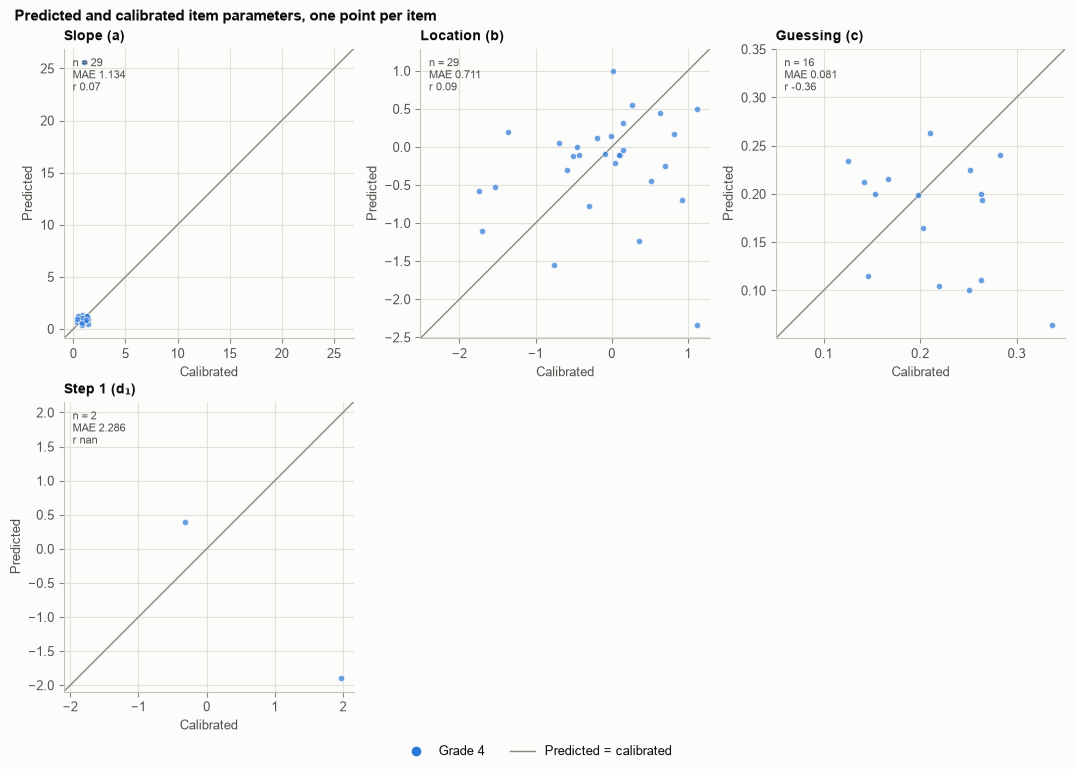

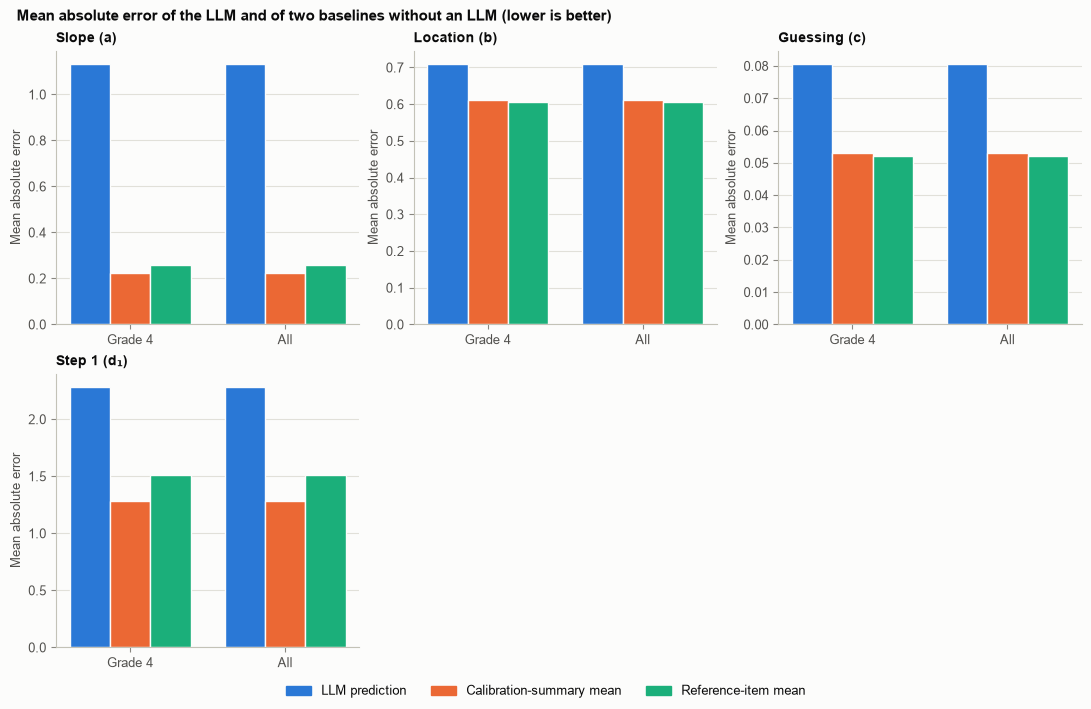

In [14]:
display(plots.predicted_vs_calibrated(results.errors))
display(plots.mae_vs_baselines(results.errors))

### Results of the first runs on 2026-10-04

`llama3.2` predicted 29 of the first 30 items, all of TIMSS 1995 grade 4, in about 10 to 15 seconds per item.
3 of the 32 requests repeated themselves until `PARAMETER_MAX_TOKENS` and were left for a rerun (T4B is still missing).
On these items it does worse than both baselines that need no LLM:

- Location: the mean absolute error is 0.71, against 0.61 for the calibration-summary mean and 0.61 for the reference-item mean, and the predictions correlate 0.09 with the calibrated locations.
- Slope: the mean absolute error is 0.30 without U3A, whose slope it put at 25.6 (calibrated: 1.01), against 0.22 and 0.26 for the baselines; with U3A it is 1.13.
- Guessing: the mean absolute error is 0.081, against 0.053 and 0.052.

So `llama3.2`, a 3-billion-parameter model without reasoning, serves to test the setup rather than to predict; a larger local model, or `google/gemini-3.8-flash` on OpenRouter (location mean absolute error 0.39 in `predict_item_parameters.ipynb`), is the comparison that matters.